# California Housing Price Prediction — Regression Assignment


### Objectives
- Dataset ko analyze karna aur samajhna
- Missing values handle karna
- Categorical column ko encode karna
- Numeric features ko scale karna
- Multiple regression models train karna aur compare karna
- Best model select karke hyperparameter tuning se performance improve karna


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)



In [4]:
df = pd.read_csv('housing.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (20640, 10)

First 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
# Missing values check
print("Missing Values per Column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

Missing Values per Column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Total missing values: 207


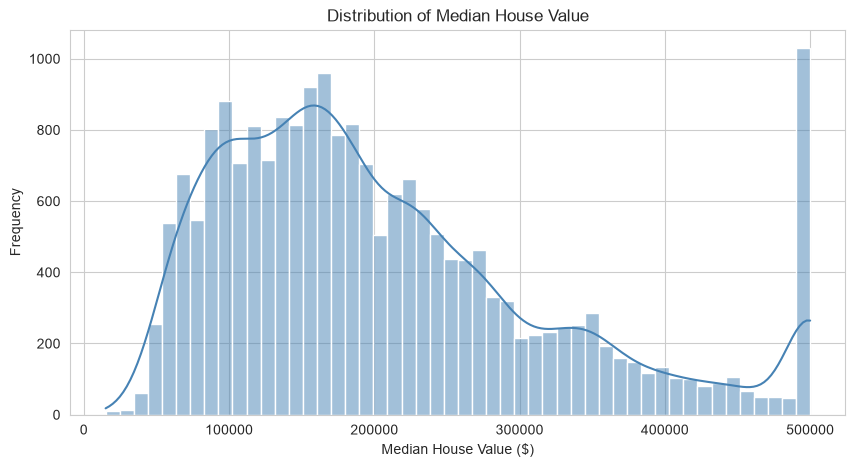

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')
plt.show()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


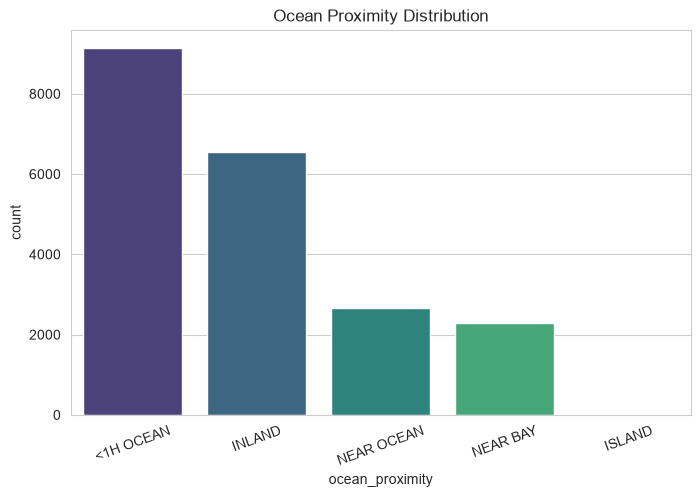

In [9]:
print(df['ocean_proximity'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='ocean_proximity', order=df['ocean_proximity'].value_counts().index, palette='viridis')
plt.title('Ocean Proximity Distribution')
plt.xticks(rotation=20)
plt.show()

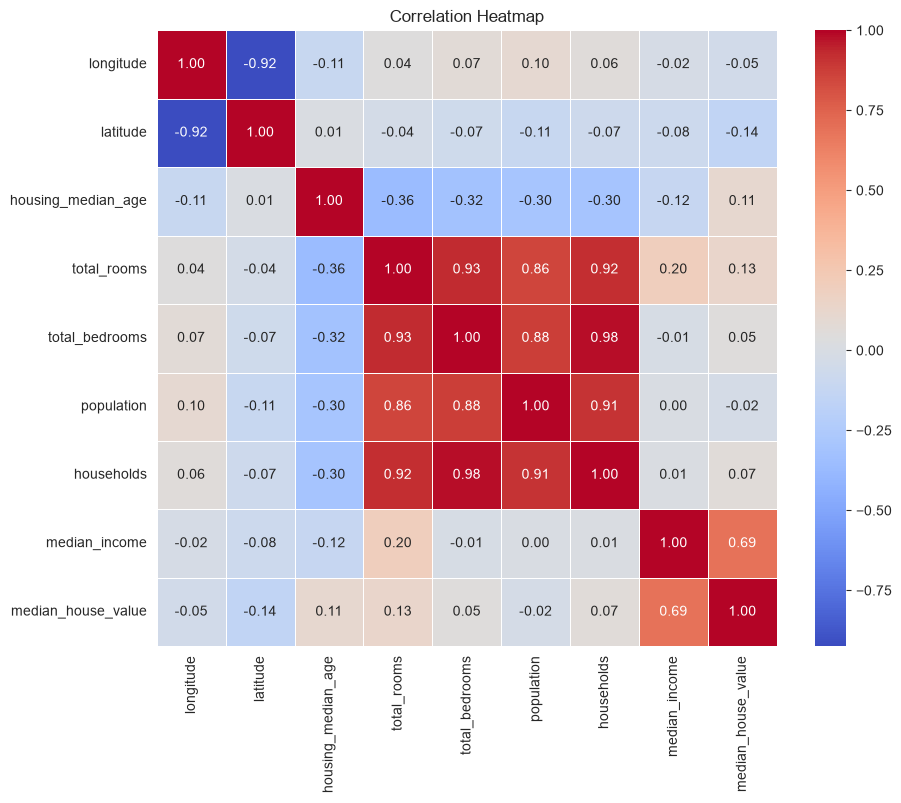

In [10]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

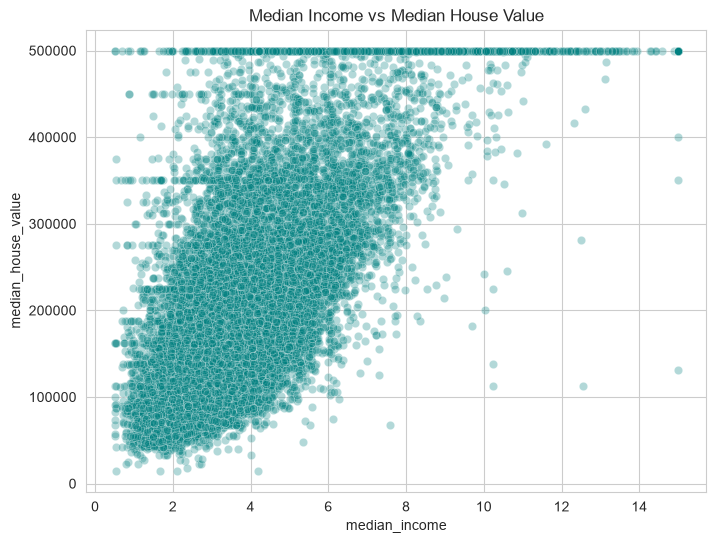

In [11]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.3, color='teal')
plt.title('Median Income vs Median House Value')
plt.show()

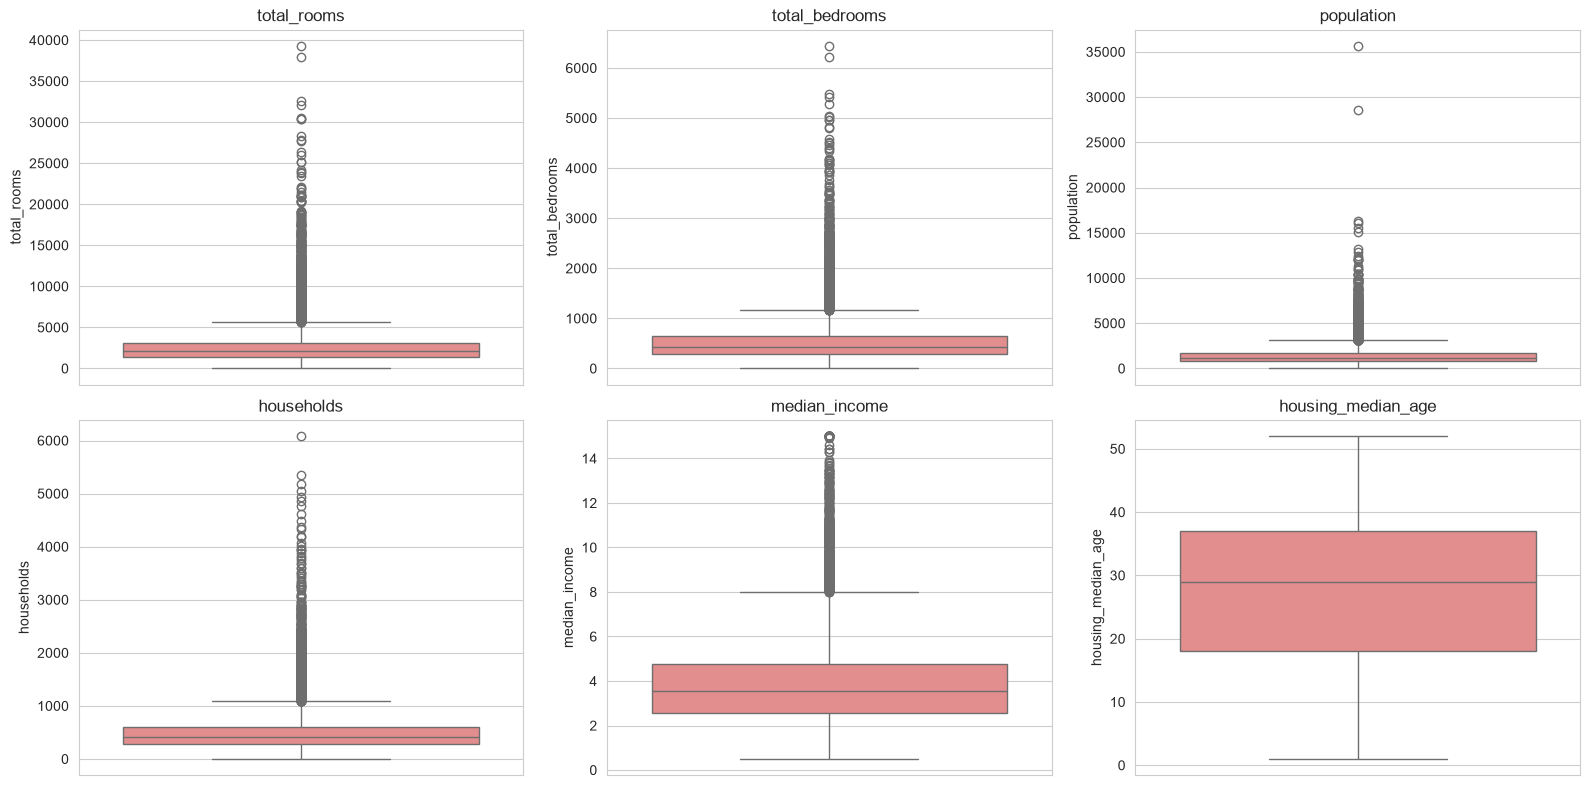

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
cols_to_check = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'housing_median_age']

for ax, col in zip(axes.flatten(), cols_to_check):
    sns.boxplot(y=df[col], ax=ax, color='lightcoral')
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Data Preprocessing


In [13]:
print("Before filling - missing values:", df['total_bedrooms'].isnull().sum())

df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

print("After filling - missing values:", df['total_bedrooms'].isnull().sum())

Before filling - missing values: 207
After filling - missing values: 0


In [14]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe()

,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000
mean,5.429000,0.213794,3.070655
std,2.474173,0.065248,10.386050
min,0.846154,0.037151,0.692308
25%,4.440716,0.175225,2.429741
50%,5.229129,0.203159,2.818116
75%,6.052381,0.240126,3.282261
max,141.909091,2.824675,1243.333333


In [15]:
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

print("New columns after encoding:")
print(df_encoded.columns.tolist())
df_encoded.head()

New columns after encoding:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


In [17]:
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (16512, 15)
Testing set shape: (4128, 15)


In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done")
print("Scaled training data sample mean (should be ~0):", X_train_scaled.mean().round(3))
print("Scaled training data sample std (should be ~1):", X_train_scaled.std().round(3))

Feature scaling done
Scaled training data sample mean (should be ~0): 0.0
Scaled training data sample std (should be ~1): 1.0


## Model Building — Multiple Regression Models

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Decision Tree Regressor
5. Random Forest Regressor
6. Gradient Boosting Regressor
7. K-Nearest Neighbors Regressor

In [22]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=42),
    'Lasso Regression': Lasso(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN Regressor': KNeighborsRegressor()
}

results = []

for name, model in models.items():
    # Model train karna scaled data par
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Metrics calculate karna
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    })

    print(f" {name} trained")

 Linear Regression trained
 Ridge Regression trained
 Lasso Regression trained
 Decision Tree trained
 Random Forest trained
 Gradient Boosting trained
 KNN Regressor trained


## Model Evaluation & Comparison


- **MAE (Mean Absolute Error):**  
- **MSE (Mean Squared Error):** 
- **RMSE (Root Mean Squared Error):** 
- **R² Score:**

In [23]:
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest,32329.317706,2.533204e+09,50330.947164,0.806686
1,Gradient Boosting,36591.406603,2.874713e+09,53616.349302,0.780625
2,KNN Regressor,41745.599855,3.857248e+09,62106.747677,0.705645
3,Ridge Regression,50888.319653,5.280398e+09,72666.348221,0.597042
4,Lasso Regression,50888.053644,5.280496e+09,72667.021851,0.597035
5,Linear Regression,50888.660016,5.280716e+09,72668.538379,0.597018
6,Decision Tree,44285.797723,5.291928e+09,72745.641050,0.596162


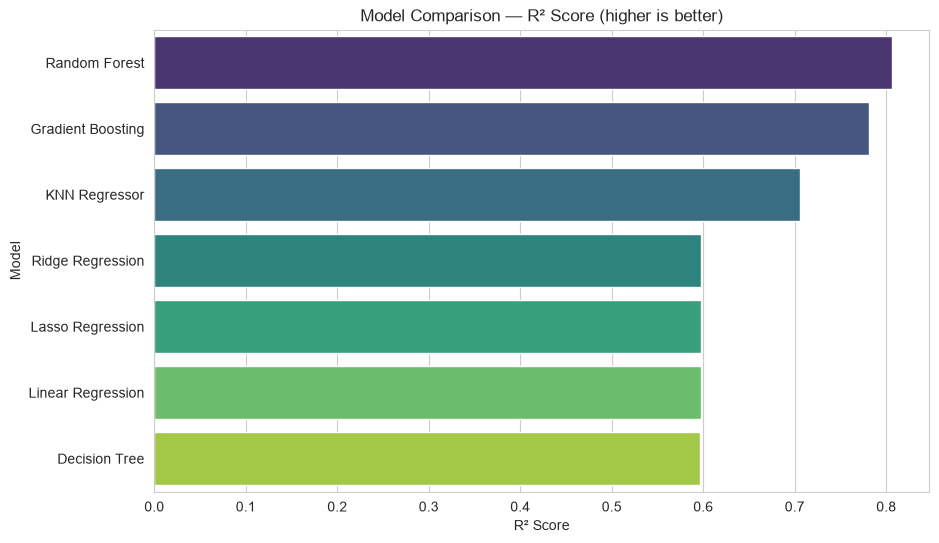

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='R2 Score', y='Model', palette='viridis')
plt.title('Model Comparison — R² Score (higher is better)')
plt.xlabel('R² Score')
plt.show()

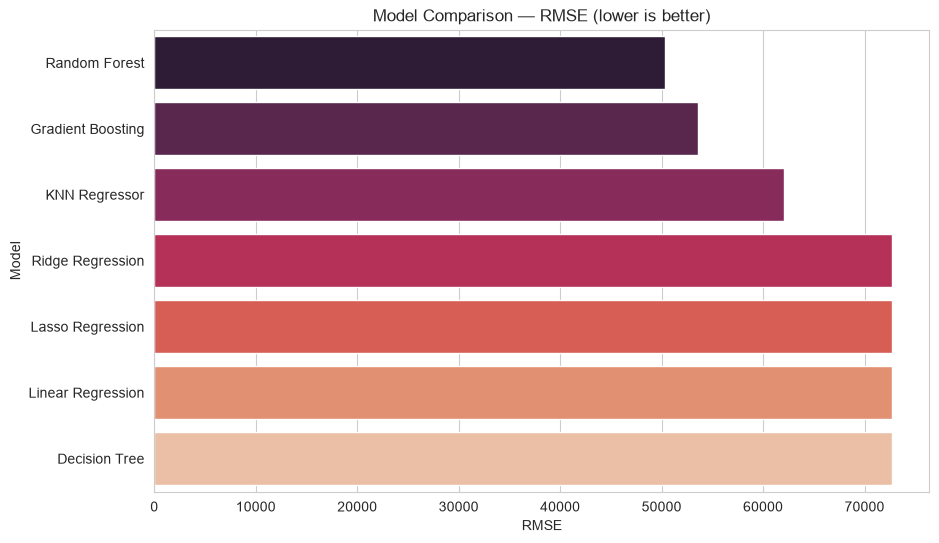

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='RMSE', y='Model', palette='rocket')
plt.title('Model Comparison — RMSE (lower is better)')
plt.xlabel('RMSE')
plt.show()

In [27]:
best_model_name = results_df.iloc[0]['Model']
print(f"Best Performing Model (before tuning): {best_model_name}")
print(f"R2 Score: {results_df.iloc[0]['R2 Score']:.4f}")
print(f"RMSE: {results_df.iloc[0]['RMSE']:.2f}")

Best Performing Model (before tuning): Random Forest
R2 Score: 0.8067
RMSE: 50330.95


## Hyperparameter Tuning & Final Model



In [28]:
# Random Forest ko tune kar rahe hain (typically best baseline model is dataset ke liye)
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [15, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\n Best Parameters found:")
print(grid_search.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits

 Best Parameters found:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 150}


In [30]:
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Performance:")
print(f"MAE  : {mae_tuned:.2f}")
print(f"MSE  : {mse_tuned:.2f}")
print(f"RMSE : {rmse_tuned:.2f}")
print(f"R2   : {r2_tuned:.4f}")

# Before vs After comparison
before_r2 = results_df[results_df['Model'] == 'Random Forest']['R2 Score'].values[0]
print(f"\n Improvement: R2 went from {before_r2:.4f} (default) to {r2_tuned:.4f} (tuned)")

Tuned Random Forest Performance:
MAE  : 32259.34
MSE  : 2512453182.45
RMSE : 50124.38
R2   : 0.8083

 Improvement: R2 went from 0.8067 (default) to 0.8083 (tuned)


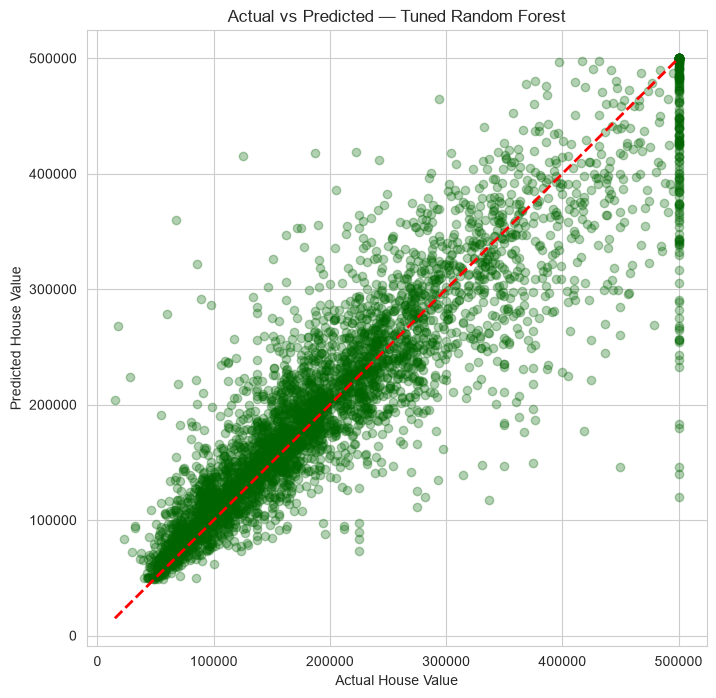

In [33]:
# Actual vs Predicted values plot (tuned model)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_tuned, alpha=0.3, color='darkgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted — Tuned Random Forest')
plt.show()

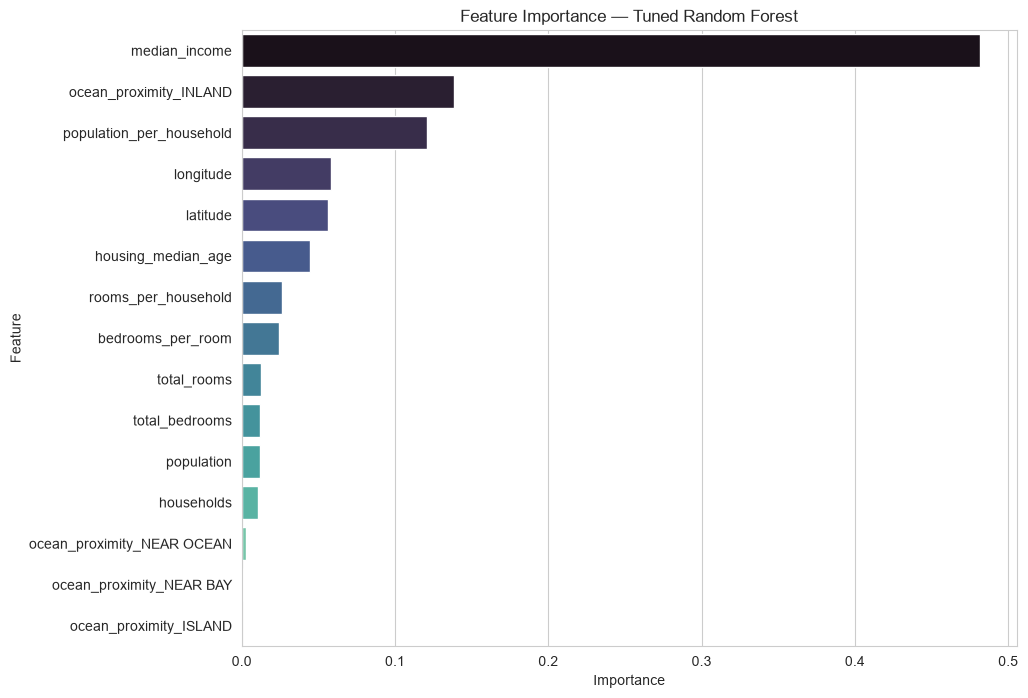

,Feature,Importance
7,median_income,0.481483
11,ocean_proximity_INLAND,0.138320
10,population_per_household,0.121101
0,longitude,0.057958
1,latitude,0.056374
2,housing_median_age,0.044409
8,rooms_per_household,0.026062
9,bedrooms_per_room,0.024252
3,total_rooms,0.012612
4,total_bedrooms,0.012006


In [34]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='mako')
plt.title('Feature Importance — Tuned Random Forest')
plt.show()

feature_importance